In [2]:
import os

data_dir = '/kaggle/input/ganbrainmri/Training'
os.listdir(data_dir)

['pituitary', 'notumor', 'meningioma', 'glioma']

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

def load_and_preprocess_images(data_dir, target_size=(256, 256)):
    images = []
    for img_name in os.listdir(data_dir):
        if img_name.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(data_dir, img_name)
            img = load_img(img_path, color_mode='grayscale', target_size=target_size)
            img_array = img_to_array(img)
            images.append(img_array)
    
    return np.array(images)

def normalize_images(images):
    # Normalize to [-1, 1] range
    return (images / 127.5) - 1

def create_datasets(images, batch_size=32, validation_split=0.2):
    # Split the data into training and validation sets
    train_images, val_images = train_test_split(images, test_size=validation_split, random_state=42)
    
    # Create TensorFlow datasets
    train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(1000).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices(val_images).batch(batch_size)
    
    return train_dataset, val_dataset

def preprocess_mri_dataset(data_dir, target_size=(256, 256), batch_size=32, validation_split=0.2):
    # Load and preprocess images
    images = load_and_preprocess_images(data_dir, target_size)
    
    # Normalize images
    normalized_images = normalize_images(images)
    
    # Create datasets
    train_dataset, val_dataset = create_datasets(normalized_images, batch_size, validation_split)
    
    return train_dataset, val_dataset

# Example usage
if __name__ == "__main__":
    data_dir = '/kaggle/input/ganbrainmri/Training/notumor'
    train_dataset, val_dataset = preprocess_mri_dataset(data_dir)
    
    print("Training dataset:", train_dataset)
    print("Validation dataset:", val_dataset)

Training dataset: <_BatchDataset element_spec=TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)>
Validation dataset: <_BatchDataset element_spec=TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)>


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt

def build_generator(latent_dim, output_shape):
    model = models.Sequential([
        layers.Dense(16 * 16 * 256, input_dim=latent_dim),
        layers.Reshape((16, 16, 256)),
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(32, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(16, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Conv2DTranspose(1, kernel_size=4, strides=1, padding='same', activation='tanh')
    ])
    return model

def build_discriminator(input_shape):
    model = models.Sequential([
        layers.Conv2D(16, kernel_size=4, strides=2, padding='same', input_shape=input_shape),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(32, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(64, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(128, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(256, kernel_size=4, strides=2, padding='same'),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

class GAN(models.Model):
    def __init__(self, latent_dim, input_shape):
        super(GAN, self).__init__()
        self.latent_dim = latent_dim
        self.generator = build_generator(latent_dim, input_shape)
        self.discriminator = build_discriminator(input_shape)

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super(GAN, self).compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(latent_vectors, training=True)

            real_output = self.discriminator(real_images, training=True)
            fake_output = self.discriminator(generated_images, training=True)

            gen_loss = self.loss_fn(tf.ones_like(fake_output), fake_output)
            disc_loss = self.loss_fn(tf.ones_like(real_output), real_output) + \
                        self.loss_fn(tf.zeros_like(fake_output), fake_output)

        gradients_of_generator = gen_tape.gradient(gen_loss, self.generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.g_optimizer.apply_gradients(zip(gradients_of_generator, self.generator.trainable_variables))
        self.d_optimizer.apply_gradients(zip(gradients_of_discriminator, self.discriminator.trainable_variables))

        return {"d_loss": disc_loss, "g_loss": gen_loss}

def train_gan(gan, dataset, epochs, batch_size):
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        for batch in dataset:
            gan.train_step(batch)
        
        # Generate and save sample images
        if (epoch + 1) % 10 == 0:
            generate_and_save_images(gan, epoch + 1)

def generate_and_save_images(gan, epoch):
    test_input = tf.random.normal([16, gan.latent_dim])
    generated_images = gan.generator(test_input, training=False)
    
    fig = plt.figure(figsize=(4, 4))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(generated_images[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        plt.axis('off')
    plt.savefig(f'generated_images_epoch_{epoch}.png')
    plt.close()

# Hyperparameters
latent_dim = 100
input_shape = (256, 256, 1)
batch_size = 32
epochs = 100
learning_rate = 0.0002
beta_1 = 0.5

# Create and compile the GAN
gan = GAN(latent_dim, input_shape)
gan.compile(
    g_optimizer=optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1),
    d_optimizer=optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1),
    loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=False)
)

# Assuming you have already preprocessed your dataset
# train_dataset = ...

# Train the GAN
train_gan(gan, train_dataset, epochs, batch_size)

/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/conda/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def get_generator_input_shape(generator):
    # Get the input shape of the generator
    if hasattr(generator, 'input_shape'):
        input_shape = generator.input_shape
    else:
        # If the model doesn't have an input_shape attribute, get it from the first layer
        input_shape = generator.layers[0].input_shape

    if isinstance(input_shape, list):
        input_shape = input_shape[0]

    # Remove the batch size dimension if it's None
    if input_shape[0] is None:
        input_shape = input_shape[1:]

    return input_shape

def generate_images_in_batches(generator, num_images=1000, batch_size=32):
    input_shape = get_generator_input_shape(generator)
    latent_dim = np.prod(input_shape)  # Calculate total number of elements
    num_batches = (num_images + batch_size - 1) // batch_size
    generated_images = []
    for _ in range(num_batches):
        batch_size = min(batch_size, num_images - len(generated_images))
        latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
        # Reshape latent vectors to match the input shape expected by the generator
        reshaped_vectors = tf.reshape(latent_vectors, (batch_size,) + input_shape)
        batch_images = generator(reshaped_vectors, training=False)
        generated_images.append(batch_images)
        if len(generated_images) * batch_size >= num_images:
            break
    return tf.concat(generated_images, axis=0)[:num_images]

def visualize_generated_images(generated_images, num_images=25):
    fig, axes = plt.subplots(5, 5, figsize=(15, 15))
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            ax.imshow(generated_images[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('generated_images.png')
    plt.close()

def interpolate_latent_space(generator, num_steps=10):
    input_shape = get_generator_input_shape(generator)
    latent_dim = np.prod(input_shape)
    start_vector = tf.random.normal(shape=(1, latent_dim))
    end_vector = tf.random.normal(shape=(1, latent_dim))

    alphas = np.linspace(0, 1, num_steps)
    interpolated_vectors = tf.convert_to_tensor(
        [(1 - alpha) * start_vector + alpha * end_vector for alpha in alphas]
    )
    # Reshape interpolated vectors
    interpolated_vectors = tf.reshape(interpolated_vectors, (num_steps,) + input_shape)

    interpolated_images = generator(interpolated_vectors, training=False)

    fig, axes = plt.subplots(1, num_steps, figsize=(20, 4))
    for i, ax in enumerate(axes):
        ax.imshow(interpolated_images[i, :, :, 0] * 0.5 + 0.5, cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('latent_space_interpolation.png')
    plt.close()

def visualize_latent_space(generator, num_samples=1000):
    input_shape = get_generator_input_shape(generator)
    latent_dim = np.prod(input_shape)
    latent_vectors = tf.random.normal(shape=(num_samples, latent_dim))
    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(latent_vectors)

    plt.figure(figsize=(10, 10))
    plt.scatter(latent_2d[:, 0], latent_2d[:, 1], alpha=0.5)
    plt.title('t-SNE visualization of latent space')
    plt.savefig('latent_space_tsne.png')
    plt.close()

def total_variation(images):
    pixel_dif1 = images[:, 1:, :, :] - images[:, :-1, :, :]
    pixel_dif2 = images[:, :, 1:, :] - images[:, :, :-1, :]
    total_var = tf.reduce_sum(tf.abs(pixel_dif1)) + tf.reduce_sum(tf.abs(pixel_dif2))
    return total_var / tf.cast(tf.reduce_prod(tf.shape(images)), tf.float32)

def calculate_fid(real_images, generated_images):
    # This is a simplified FID calculation and should be replaced with a proper implementation
    real_mean = tf.reduce_mean(real_images, axis=0)
    generated_mean = tf.reduce_mean(generated_images, axis=0)
    return tf.reduce_mean(tf.square(real_mean - generated_mean))

def post_training_analysis(gan, train_dataset, num_images=1000, batch_size=32):
    # Generate images in batches
    generated_images = generate_images_in_batches(gan.generator, num_images, batch_size)

    # Visualize generated images
    visualize_generated_images(generated_images[:25])

    # Interpolate in latent space
    interpolate_latent_space(gan.generator)

    # Visualize latent space
    visualize_latent_space(gan.generator, num_samples=1000)

    # Evaluate image quality
    tv_score = total_variation(generated_images[:100])  # Calculate TV score for first 100 images
    print(f"Total Variation score: {tv_score}")

    # Calculate FID score
    real_images = next(iter(train_dataset))  # Get a batch of real images from the training dataset
    fid_score = calculate_fid(real_images, generated_images[:len(real_images)])
    print(f"FID score (simplified): {fid_score}")

# Assuming you have your trained GAN model and train_dataset
# gan = ...  # Your trained GAN model
# train_dataset = ...  # Your training dataset

# Run post-training analysis
post_training_analysis(gan, train_dataset, num_images=1000, batch_size=32)

Total Variation score: 0.14444813132286072
FID score (simplified): 0.013578959740698338


In [11]:
def evaluate_gan(gan, val_dataset):
    # Generate images from the trained GAN
    num_images = 1000  # Number of images to generate for evaluation
    latent_dim = gan.latent_dim
    generated_images = []
    
    for _ in range(num_images // batch_size):
        latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
        batch_generated_images = gan.generator(latent_vectors, training=False)
        generated_images.append(batch_generated_images.numpy())
    
    generated_images = np.concatenate(generated_images)
    
    # Prepare real images for evaluation
    real_images = [image for image in val_dataset]
    real_images = np.concatenate(real_images)

    # Compute FID and IS
    fid_score = calculate_fid(real_images, generated_images)
    is_score = inception_score(generated_images)
    
    print(f"FID Score: {fid_score}")
    print(f"Inception Score: {is_score}")

evaluate_gan(gan, val_dataset)

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


ValueError: Input 0 of layer "functional_3" is incompatible with the layer: expected shape=(None, 299, 299, 3), found shape=(32, 256, 256)

In [10]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras import backend as K
import numpy as np

def inception_score(images, batch_size=32, splits=10):
    model = InceptionV3(include_top=True, weights='imagenet')
    model = tf.keras.Model(inputs=model.inputs, outputs=model.layers[-2].output)
    
    def _softmax(x):
        return K.softmax(x)
    
    def _kl_divergence(p, q):
        return np.sum(p * np.log(p / q), axis=1)
    
    def _calculate_scores(preds):
        scores = []
        for i in range(splits):
            split_preds = preds[i * (len(preds) // splits):(i + 1) * (len(preds) // splits)]
            split_preds = _softmax(split_preds)
            kl_div = _kl_divergence(np.mean(split_preds, axis=0), split_preds)
            scores.append(np.exp(np.mean(kl_div)))
        return np.mean(scores)
    
    preds = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        batch = preprocess_input(np.array(batch))
        batch_preds = model.predict(batch)
        preds.append(batch_preds)
    
    preds = np.concatenate(preds)
    score = _calculate_scores(preds)
    return score

# Example usage:
# images = [preprocess_your_image_function(img_path) for img_path in image_paths]
# is_score = inception_score(images)


In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from scipy.linalg import sqrtm

def preprocess_images_for_inception(images, target_size=(299, 299)):
    processed_images = []
    for img in images:
        img = tf.image.resize(img, target_size)
        img = tf.image.grayscale_to_rgb(img)  # Convert grayscale to RGB
        img = preprocess_input(img)  # Preprocess for InceptionV3
        processed_images.append(img)
    return np.array(processed_images)

def calculate_fid(real_images, generated_images):
    model = InceptionV3(include_top=False, pooling='avg', weights='imagenet')
    
    def get_features(images):
        images = preprocess_images_for_inception(images)
        features = model.predict(images)
        return features
    
    def calculate_activation_statistics(features):
        mean = np.mean(features, axis=0)
        cov = np.cov(features, rowvar=False)
        return mean, cov
    
    real_features = get_features(real_images)
    generated_features = get_features(generated_images)
    
    real_mean, real_cov = calculate_activation_statistics(real_features)
    gen_mean, gen_cov = calculate_activation_statistics(generated_features)
    
    mean_diff = real_mean - gen_mean
    cov_sqrt, _ = sqrtm(real_cov @ gen_cov, disp=False)
    fid = np.sum(mean_diff**2) + np.trace(real_cov + gen_cov - 2 * cov_sqrt)
    return fid

# Example usage
# Assuming `real_images` and `generated_images` are numpy arrays
# with shape (num_samples, height, width, channels)


In [17]:
import tensorflow as tf
import numpy as np

def inception_score(images, batch_size=32, splits=10):
    model = tf.keras.applications.InceptionV3(include_top=True, weights='imagenet')
    model = tf.keras.Model(inputs=model.inputs, outputs=model.layers[-2].output)
    
    def preprocess_images(images):
        images = [tf.image.resize(img, (299, 299)) for img in images]
        images = [tf.image.grayscale_to_rgb(img) for img in images]  # Convert grayscale to RGB
        images = tf.keras.applications.inception_v3.preprocess_input(np.array(images))
        return images
    
    def _softmax(x):
        return tf.nn.softmax(x)

    def _kl_divergence(p, q):
        return np.sum(p * np.log(p / q), axis=1)
    
    def _calculate_scores(preds):
        scores = []
        for i in range(splits):
            split_preds = preds[i * (len(preds) // splits):(i + 1) * (len(preds) // splits)]
            split_preds = _softmax(split_preds)
            kl_div = _kl_divergence(np.mean(split_preds, axis=0), split_preds)
            scores.append(np.exp(np.mean(kl_div)))
        return np.mean(scores)
    
    images = preprocess_images(images)
    preds = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        batch_preds = model.predict(batch)
        preds.append(batch_preds)
    
    preds = np.concatenate(preds)
    score = _calculate_scores(preds)
    return score

# Example usage
# Assuming `images` is a numpy array with shape (num_samples, height, width, channels)


In [18]:
def evaluate_gan(gan, val_dataset):
    num_images = 1000
    latent_dim = gan.latent_dim
    generated_images = []
    
    for _ in range(num_images // batch_size):
        latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
        batch_generated_images = gan.generator(latent_vectors, training=False)
        generated_images.append(batch_generated_images.numpy())
    
    generated_images = np.concatenate(generated_images)
    
    # Prepare real images for evaluation
    real_images = []
    for batch in val_dataset:
        real_images.append(batch.numpy())
    real_images = np.concatenate(real_images)
    
    # Compute FID and IS
    fid_score = calculate_fid(real_images, generated_images)
    is_score = inception_score(generated_images)
    
    print(f"FID Score: {fid_score}")
    print(f"Inception Score: {is_score}")
evaluate_gan(gan, val_dataset)

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 548ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━

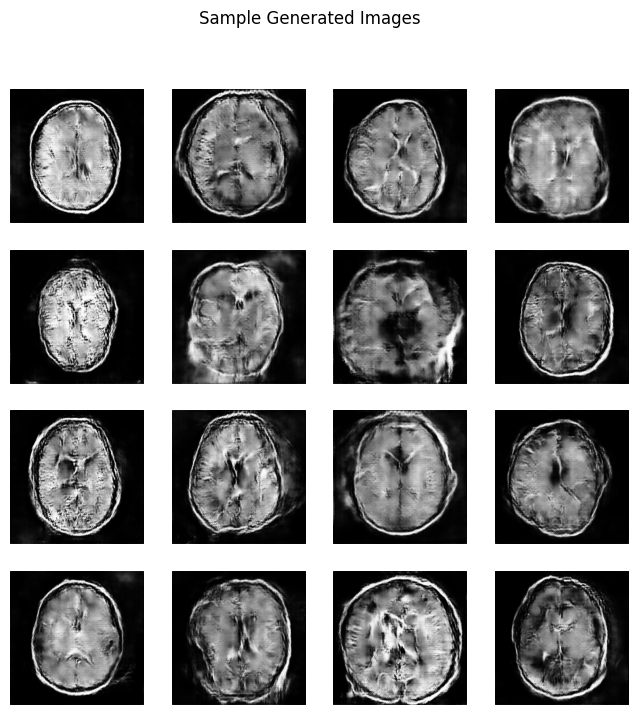

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def generate_images(gan, latent_dim, num_images=16):
    """
    Generate images using the GAN's generator.

    Parameters:
        gan (GAN model): The trained GAN model.
        latent_dim (int): The dimensionality of the latent space.
        num_images (int): Number of images to generate.

    Returns:
        numpy array: Generated images.
    """
    # Generate random latent vectors
    latent_vectors = tf.random.normal(shape=(num_images, latent_dim))
    
    # Generate images from latent vectors
    generated_images = gan.generator(latent_vectors, training=False)
    
    # Convert the generated images to numpy arrays and scale to [0, 1]
    generated_images = (generated_images + 1) / 2.0  # Assuming images are normalized to [-1, 1]

    return generated_images.numpy()

def plot_generated_images(images, title="Generated Images"):
    """
    Plot multiple generated images in a grid.

    Parameters:
        images (numpy array): The images to display.
        title (str): Title of the plot.
    """
    num_images = images.shape[0]
    grid_size = int(np.sqrt(num_images))
    
    plt.figure(figsize=(8, 8))
    for i in range(num_images):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(images[i, :, :, 0], cmap='gray')  # Assuming grayscale images; adjust for RGB if needed
        plt.axis('off')
    
    plt.suptitle(title)
    plt.show()

# Example usage
latent_dim = 100  # The dimension of the latent space used in your GAN
num_images = 16    # Number of images to generate

# Generate images from the GAN model
generated_images = generate_images(gan, latent_dim, num_images)

# Plot the generated images
plot_generated_images(generated_images, title="Sample Generated Images")
